In this project we will complete the following steps and answer the following questions:
1) Load your datasets and perform some simple exploratory data analysis.
2) Create a new column to represent the like-dislike ratio (likes divided by dislikes) for the videos in each dataset.
3) What is the average like-dislike ratio for all of the videos? (average number of likes per video divided by the average number of dislikes per video).
4) Perform data manipulation to find the average number of likes per video for the US and GB in the year 2018.
5) **Business report:** Your client hypothesizes that the most polarizing videos get shared the most. Analyze the data to determine whether your client is correct, and what other metrics should be investigated. Be sure to define any terms or cutoffs you make in the data. Present your findings in a short report for the client to review.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns

# Loading the table
df = pd.concat([
    pd.read_parquet('output/all_videos_final.parquet_0_0_0.snappy.parquet'),
    pd.read_parquet('output/all_videos_final.parquet_0_1_0.snappy.parquet'),
    pd.read_parquet('output/all_videos_final.parquet_0_2_0.snappy.parquet'),
    pd.read_parquet('output/all_videos_final.parquet_0_3_0.snappy.parquet')
])

print(df.shape)
print(df.dtypes)
display(df.head(10))

(9890, 11)
_COL_0                     str
_COL_1                     str
_COL_2                     str
_COL_3                     str
_COL_4                     str
_COL_5                  object
_COL_6                  object
_COL_7                  object
_COL_8                  object
_COL_9     datetime64[ms, UTC]
_COL_10                 object
dtype: object


,_COL_0,_COL_1,_COL_2,_COL_3,_COL_4,_COL_5,_COL_6,_COL_7,_COL_8,_COL_9,_COL_10
0,fIQ2Ty2OL34,James Harden Triple-Double 2017.11.09 vs Cavs ...,FreeDawkins,Sports,US,18573,420,10,236,2017-11-10 04:00:52+00:00,1
1,64IIfxDrhJY,Titanic (2017) - Dolby Vision Trailer,Paramount Pictures,Film & Animation,US,17129,455,18,101,2017-11-15 13:32:00+00:00,1
2,ZDMgHk2DjoQ,CAKE BOSS COUPLES FACE OFF | Shawn Johnson,Shawn Johnson East,People & Blogs,GB,134067,3805,118,514,2017-11-04 15:00:02+00:00,2
3,0WPYpeJA__U,John Mayer On Andy Cohen’s Annoying Habit | WWHL,Watch What Happens Live with Andy Cohen,Entertainment,US,35467,227,8,48,2017-11-28 12:59:47+00:00,1
4,VSKuhdmYkUU,Liam Payne and Rita Ora: For You (Fifty Shades...,The Tonight Show Starring Jimmy Fallon,Comedy,GB,518852,37088,336,1927,2018-02-01 12:00:02+00:00,1
5,K45mFsyZxtU,Fox & Friends Cold Open - SNL,Saturday Night Live,Entertainment,US,2613507,21307,5113,4256,2018-02-04 08:57:42+00:00,3
6,XQSvN2Wd5MQ,International Dunkin' Donuts Taste Test,Good Mythical Morning,Entertainment,US,716521,23381,375,2871,2018-06-11 10:00:02+00:00,1
7,IbmvDn6I6sI,Operation Redwing - Kickapoo 35735,Lawrence Livermore National Laboratory,Science & Technology,US,30361,26,4,6,2017-12-14 15:59:41+00:00,1
8,JQBrUjPaCNw,I Got Transformed Into Margot Robbie | Beauty ...,Refinery29,Howto & Style,US,15400,495,22,37,2017-12-21 16:00:01+00:00,1
9,vU7v5A5P8BM,Tapper cuts off Trump adviser interview: I've ...,CNN,News & Politics,US,2592824,28132,11319,35908,2018-01-07 15:34:15+00:00,1


In [2]:
# Columns names were dropped in export.
# Renaming columns
df = df.rename(columns = {
    '_COL_0': 'video_id',
    '_COL_1': 'title',
    '_COL_2': 'channel_title',
    '_COL_3': 'category_title',
    '_COL_4': 'country', 
    '_COL_5': 'views',
    '_COL_6': 'likes',
    '_COL_7': 'dislikes',
    '_COL_8': 'comment_count',
    '_COL_9': 'publish_time',
    '_COL_10': 'days_trending'})

print(df.head())
print(df.dtypes)

      video_id                                              title  \
0  fIQ2Ty2OL34  James Harden Triple-Double 2017.11.09 vs Cavs ...   
1  64IIfxDrhJY              Titanic (2017) - Dolby Vision Trailer   
2  ZDMgHk2DjoQ         CAKE BOSS COUPLES FACE OFF | Shawn Johnson   
3  0WPYpeJA__U   John Mayer On Andy Cohen’s Annoying Habit | WWHL   
4  VSKuhdmYkUU  Liam Payne and Rita Ora: For You (Fifty Shades...   

                             channel_title    category_title country   views  \
0                              FreeDawkins            Sports      US   18573   
1                       Paramount Pictures  Film & Animation      US   17129   
2                       Shawn Johnson East    People & Blogs      GB  134067   
3  Watch What Happens Live with Andy Cohen     Entertainment      US   35467   
4   The Tonight Show Starring Jimmy Fallon            Comedy      GB  518852   

   likes dislikes comment_count              publish_time days_trending  
0    420       10           23

In [32]:
# Views, likes, dislikes, comment count, and days trending should be integers
# Fix Snowflake Decimal type export issue
df[['views', 'likes', 'dislikes', 'comment_count', 'days_trending']] = (
    df[['views', 'likes', 'dislikes', 'comment_count', 'days_trending']].astype(float)
)

# publish_time should be datetime
df.publish_time = pd.to_datetime(df.publish_time)

print(df.dtypes)

video_id                          str
title                             str
channel_title                     str
category_title                    str
country                           str
views                         float64
likes                         float64
dislikes                      float64
comment_count                 float64
publish_time      datetime64[ms, UTC]
days_trending                 float64
dtype: object


In [33]:
# Creating df for each country
df_US_video = df[df['country'] == 'US']
df_GB_video = df[df['country'] == 'GB']

print("df_US duplicated sum:", df_US_video.duplicated().sum())
print("df_US unique video_id", df_US_video.video_id.nunique())
print("df_GB duplicated sum:", df_GB_video.duplicated().sum())
print("df_GB unique video_id:", df_GB_video.video_id.nunique())
print("df_US unique category_title:", df_US_video.category_title.nunique())
print("df_GB unique category_title:", df_GB_video.category_title.nunique())

df_US duplicated sum: 0
df_US unique video_id 6351
df_GB duplicated sum: 0
df_GB unique video_id: 3272
df_US unique category_title: 16
df_GB unique category_title: 16


In [34]:
# the dataframe has been aggregated previously in pipeline
# adding likes to dislike ratio column
# checking for zero dislikes as they will impact calculations
df_US_zero_dislikes = df_US_video[df_US_video['dislikes'] == 0]
print(df_US_zero_dislikes.count())
df_GB_zero_dislikes = df_GB_video[df_GB_video['dislikes'] == 0]
print(df_GB_zero_dislikes.count())

video_id          99
title             99
channel_title     99
category_title    99
country           99
views             99
likes             99
dislikes          99
comment_count     99
publish_time      99
days_trending     99
dtype: int64
video_id          27
title             27
channel_title     27
category_title    27
country           27
views             27
likes             27
dislikes          27
comment_count     27
publish_time      27
days_trending     27
dtype: int64


In [ ]:
# 99 and 27 zero dislikes entries for both dataframes
# assigning NaN to zero dislikes removes 126 entries, which affects results very little
# they would be left skewing outliers that do not meaningfully add to our analysis at the moment
df_US_video['likes_to_dislikes'] = np.where(
    df_US_video['dislikes'] > 0,
    df_US_video['likes'] / df_US_video['dislikes'],
    np.nan
)
print(df_US_video.head())
print(df_US_video.isnull().sum())
df_GB_video['likes_to_dislikes'] = np.where(
    df_GB_video['dislikes'] > 0,
    df_GB_video['likes'] / df_GB_video['dislikes'],
    np.nan
)
print(df_GB_video.head())
print(df_GB_video.isnull().sum())

      video_id                                              title  \
0  fIQ2Ty2OL34  James Harden Triple-Double 2017.11.09 vs Cavs ...   
1  64IIfxDrhJY              Titanic (2017) - Dolby Vision Trailer   
3  0WPYpeJA__U   John Mayer On Andy Cohen’s Annoying Habit | WWHL   
5  K45mFsyZxtU                      Fox & Friends Cold Open - SNL   
6  XQSvN2Wd5MQ            International Dunkin' Donuts Taste Test   

                             channel_title    category_title country  \
0                              FreeDawkins            Sports      US   
1                       Paramount Pictures  Film & Animation      US   
3  Watch What Happens Live with Andy Cohen     Entertainment      US   
5                      Saturday Night Live     Entertainment      US   
6                    Good Mythical Morning     Entertainment      US   

       views    likes  dislikes  comment_count              publish_time  \
0    18573.0    420.0      10.0          236.0 2017-11-10 04:00:52+00:00   


In [36]:
# now that the dataframes are aggregated, analyzing again
print(df_US_video.describe())
print(df_GB_video.describe())

              views         likes      dislikes  comment_count  days_trending  \
count  6.490000e+03  6.490000e+03  6.490000e+03   6.490000e+03    6490.000000   
mean   1.947715e+06  5.506652e+04  3.035706e+03   6.447788e+03       6.301849   
std    6.998380e+06  1.920679e+05  3.164926e+04   3.357260e+04       4.614357   
min    5.590000e+02  0.000000e+00  0.000000e+00   0.000000e+00       1.000000   
25%    1.564422e+05  2.776000e+03  1.260000e+02   3.812500e+02       3.000000   
50%    5.137830e+05  1.184150e+04  4.430000e+02   1.289500e+03       6.000000   
75%    1.462362e+06  3.811325e+04  1.509750e+03   4.110750e+03       8.000000   
max    2.252119e+08  5.613827e+06  1.674420e+06   1.361580e+06      29.000000   

       likes_to_dislikes  
count        6391.000000  
mean           41.585878  
std            51.515533  
min             0.000000  
25%            11.681624  
50%            26.787597  
75%            53.726223  
max          1493.750000  
              views        

The newly created likes to dislikes column is working as expected but the max is 840.75 and 1493.75. The method of tracking likes to dislikes as a ratio is unstable at extremely low dislike values making analysis harder. In the future, I would suggest using dislikes as a share of dislikes and likes together. This would bound the values between 0 and 1. But a ratio is what was in the instructions so I will continue.
Many right skewed metrics exhist. For instance, US views average is 1.96M but the median is 518,107. This pattern happens across the board which indicates a small number of videos are driving a majority of the interactions.

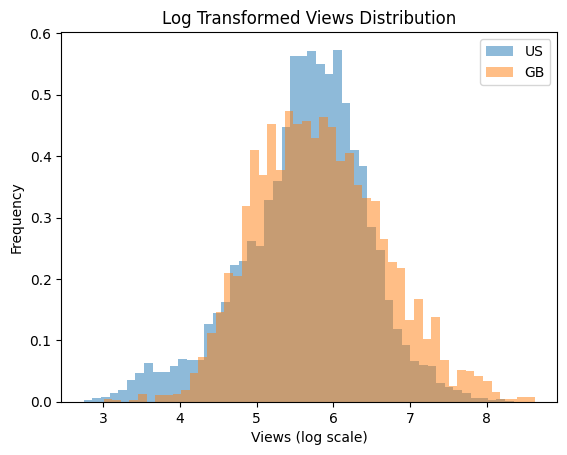

In [37]:
# histogram function
def histogram(x, xlabel, title):
    log_x_us = np.log10(df_US_video[x] + 1) # log10 will continue to be used for our heavily skewed dataset
    log_x_gb = np.log10(df_GB_video[x] + 1) # +1 to avoid issues with 0
    plt.hist(log_x_us, bins=50, alpha=0.5, density=True, label='US') # overlaying both plots at 50% transparency
    plt.hist(log_x_gb, bins=50, alpha=0.5, density=True, label='GB') # both countries overlaying scaled to fit as GB is half of US dataset
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

histogram('views', 'Views (log scale)', 'Log Transformed Views Distribution')

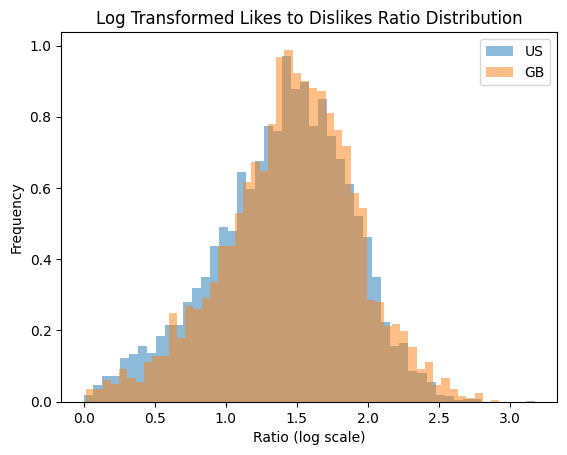

In [38]:
# Great Britain has an even tighter spread than the US but still shares the same mode of 1 million. 
# This suggests while viral videos are similar in viewership in both countries, in Great Britain those viewerships are much more dramatic
# histogram of ratio
histogram('likes_to_dislikes', 'Ratio (log scale)', 'Log Transformed Likes to Dislikes Ratio Distribution')

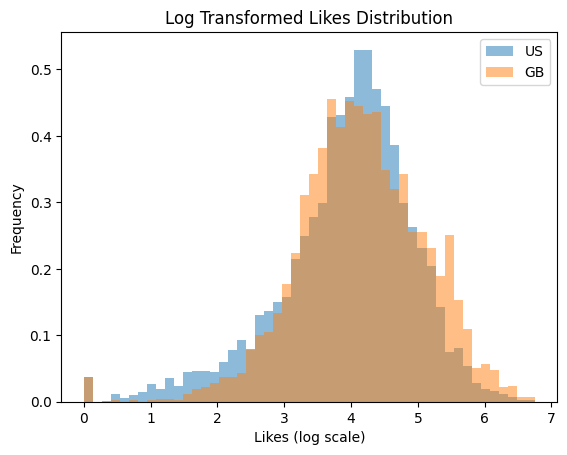

video_id             6490
title                6490
channel_title        6490
category_title       6490
country              6490
views                6490
likes                6490
dislikes             6490
comment_count        6490
publish_time         6490
days_trending        6490
likes_to_dislikes    6391
dtype: int64
video_id             3400
title                3400
channel_title        3400
category_title       3400
country              3400
views                3400
likes                3400
dislikes             3400
comment_count        3400
publish_time         3400
days_trending        3400
likes_to_dislikes    3373
dtype: int64


In [39]:
# normal log dsitrobution in like to dislike ratio for both countries
# 10^1.5 is about 31.5 likes per dislike
# a steep drop off at 100 likes per dislike and 10 likes per dislike, very polarizing videos are actually rare
# histogram of likes
histogram('likes', 'Likes (log scale)', 'Log Transformed Likes Distribution')

print(df_US_video.count()) # validating the size of each dataset
print(df_GB_video.count())

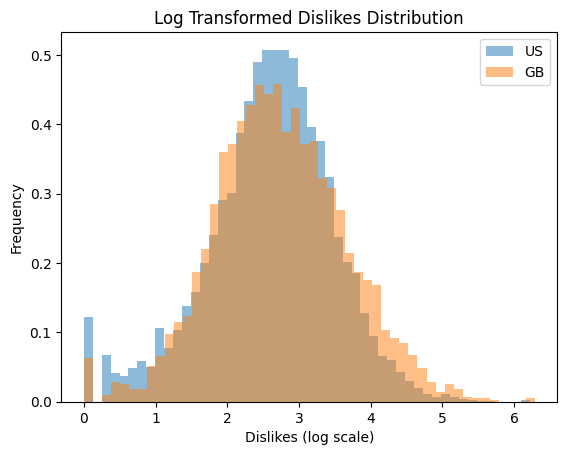

In [40]:
# histogram spread is fairly symetrical and both countries look the same
# Because density is set True, we avoid the issue of the US dataset being larger
# histogram of dislikes
histogram('dislikes', 'Dislikes (log scale)', 'Log Transformed Dislikes Distribution')

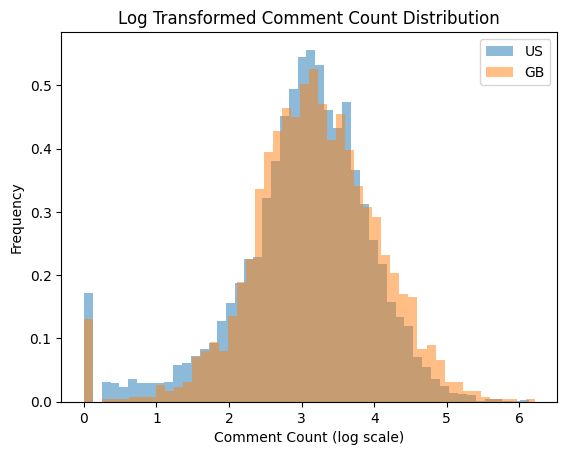

In [41]:
# comment count histogram
histogram('comment_count', 'Comment Count (log scale)', 'Log Transformed Comment Count Distribution')

In [ ]:
# histograms all look fairly symetrical in log scale and are similar between countries
# answering the question, "whats the average ratio for all videos?"
all_df_video = pd.concat([df_US_video, df_GB_video])

mean_ratio = (
    all_df_video['likes'].mean() /
    all_df_video['dislikes'].mean()
)
print(f'Average ratio of likes to dislikes: {mean_ratio:.2f}') # rounded 2 decimals
print(all_df_video.head())

Average ratio of likes to dislikes: 17.52
      video_id                                              title  \
0  fIQ2Ty2OL34  James Harden Triple-Double 2017.11.09 vs Cavs ...   
1  64IIfxDrhJY              Titanic (2017) - Dolby Vision Trailer   
3  0WPYpeJA__U   John Mayer On Andy Cohen’s Annoying Habit | WWHL   
5  K45mFsyZxtU                      Fox & Friends Cold Open - SNL   
6  XQSvN2Wd5MQ            International Dunkin' Donuts Taste Test   

                             channel_title    category_title country  \
0                              FreeDawkins            Sports      US   
1                       Paramount Pictures  Film & Animation      US   
3  Watch What Happens Live with Andy Cohen     Entertainment      US   
5                      Saturday Night Live     Entertainment      US   
6                    Good Mythical Morning     Entertainment      US   

       views    likes  dislikes  comment_count              publish_time  \
0    18573.0    420.0      10.0   

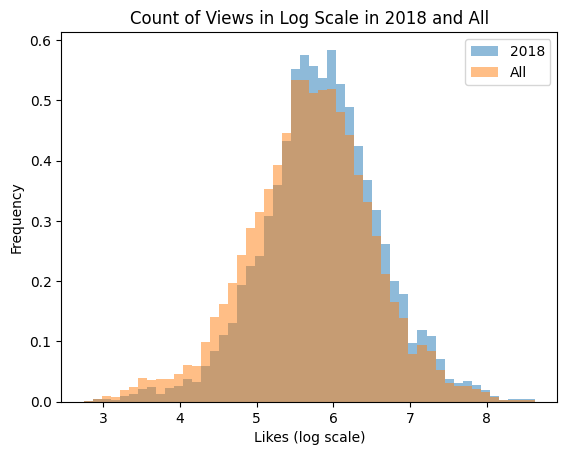

Average views in 2018: 3601182.8
Median views in 2018: 707255.5


In [43]:
# the average like-dislike ratio for all of the videos is 17.48 likes to dislikes
# finding the average number of likes per video for the US and GB in the year 2018
df_2018 = all_df_video[all_df_video['publish_time'].dt.year == 2018]
plt.hist(np.log10(df_2018.views + 1), bins=50, alpha=0.5, density=True, label='2018')
plt.hist(np.log10(all_df_video.views + 1), bins=50, alpha=0.5, density=True, label='All')
plt.xlabel('Likes (log scale)')
plt.ylabel('Frequency')
plt.title('Count of Views in Log Scale in 2018 and All')
plt.legend()
plt.show()
average_2018 = np.round(df_2018.views.mean(), 2)
print(f'Average views in 2018: {average_2018}')
median_2018 = np.round(df_2018.views.median(), 2)
print(f'Median views in 2018: {median_2018}')

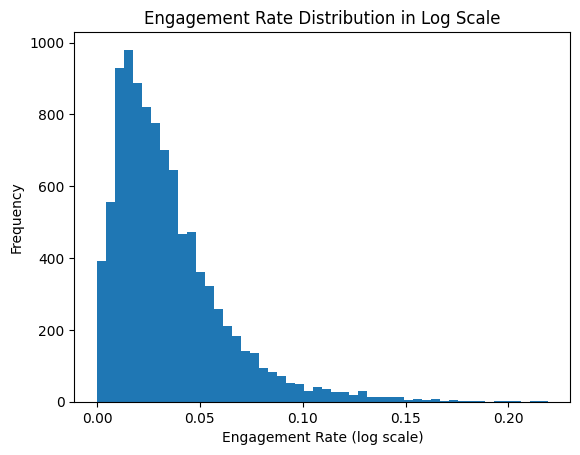

In [ ]:
# Average views in 2018 is approximately 3656840.82
# are the most polarizing videos getting shared the most?
# creating engagement rate column
all_df_video['engagement_rate'] = (
    (all_df_video['likes'] + all_df_video['dislikes'] + all_df_video['comment_count']) / # all likes, dislikes, and comments per view as "engegment rate"
    all_df_video['views']
)
plt.hist(np.log1p(all_df_video['engagement_rate']), bins=50) #log1p used to handle the right-skewed distribution; 
# note that views = 0 would cause division by zero in the engagement rate formula and should be filtered
plt.xlabel('Engagement Rate (log scale)')
plt.ylabel('Frequency')
plt.title('Engagement Rate Distribution in Log Scale')
plt.show()

During analysis I discovered an error in the engagement metric definition. After correcting the formula to (likes + dislikes + comments) / views, the distribution changed from symmetric to strongly right-skewed, which is more typical of engagement dynamics. Only a small number of videos capture a disproportionate level of interaction.

                      views     likes  dislikes  comment_count  \
views              1.000000  0.868224  0.867455       0.777625   
likes              0.868224  1.000000  0.843594       0.847337   
dislikes           0.867455  0.843594  1.000000       0.814787   
comment_count      0.777625  0.847337  0.814787       1.000000   
likes_to_dislikes  0.096678  0.366771 -0.218081       0.134308   
engagement_rate   -0.013858  0.351103  0.114740       0.331935   

                   likes_to_dislikes  engagement_rate  
views                       0.096678        -0.013858  
likes                       0.366771         0.351103  
dislikes                   -0.218081         0.114740  
comment_count               0.134308         0.331935  
likes_to_dislikes           1.000000         0.473194  
engagement_rate             0.473194         1.000000  


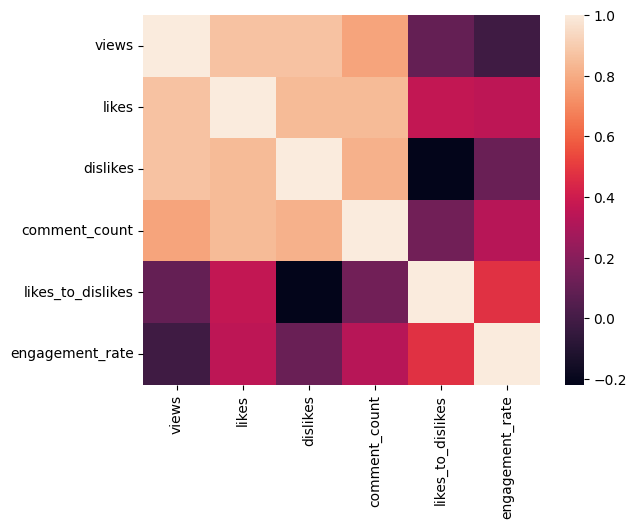

In [45]:
# creating a crosstable of variables
corr_matrix_all = all_df_video[[
    'views',
    'likes',
    'dislikes',
    'comment_count',
    'likes_to_dislikes',
    'engagement_rate']].apply(np.log1p).corr()
print(corr_matrix_all)

sns.heatmap(corr_matrix_all)
plt.show()

After correcting the engagement rate definition to (likes + dislikes + comments) / views, the relationship between views and engagement shifted from strongly positive to slightly negative. This makes more sense as views is now prominantly in the denominator, engagement measures density, and the largest audiences include higher proportions of passive viewers. 

What is correlative is views to likes (0.87), views to dislikes (0.87), and views to comments (0.78). These relationships suggest that interaction volume scales with exposure.

However, the like-to-dislike ratio shows weak correlation with views (0.10). This correlation is very weak to prove the theory that "polarizing" videos get the most shares."

One interesting relationship is likes_to_dislikes and engagement rate (0.47). The strongest correlation in our crosstable for these variables, showing some signs of increasing engagement, but not reach necessarily. 

What the data is demonstrating that views are strongly correlated with interaction counts (likes, dislikes, and comments), suggesting that interaction volume scales with exposure.

To further investigate the matter, I will split the data into quantiles of like to dislike ratio, analyzing how the highest quantile of ratio compares to the lowest.

In [46]:
# splitting ratio into quantiles
quantiles = all_df_video['likes_to_dislikes'].quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9]
)
print(quantiles)

0.10     4.917411
0.25    12.341391
0.50    27.577980
0.75    54.953991
0.90    95.268344
Name: likes_to_dislikes, dtype: float64


In [47]:
# applying quantiles to define a new column
all_df_video['Ratio Tier'] = pd.qcut(
    all_df_video['likes_to_dislikes'],
    q=3,
    labels=['High Polarization', 'Mid Polarization', 'Low Polarization'] # note: the smallest value is the highest polarization tier
)
print(all_df_video['Ratio Tier'].value_counts(normalize=True)) # validating the share of each tier

Ratio Tier
High Polarization    0.333367
Low Polarization     0.333367
Mid Polarization     0.333265
Name: proportion, dtype: float64


Ratio Tier
High Polarization    5.638699
Mid Polarization     5.809206
Low Polarization     5.746353
Name: views, dtype: float64


Text(0.5, 1.0, 'View Distribution by Polarization Tier')

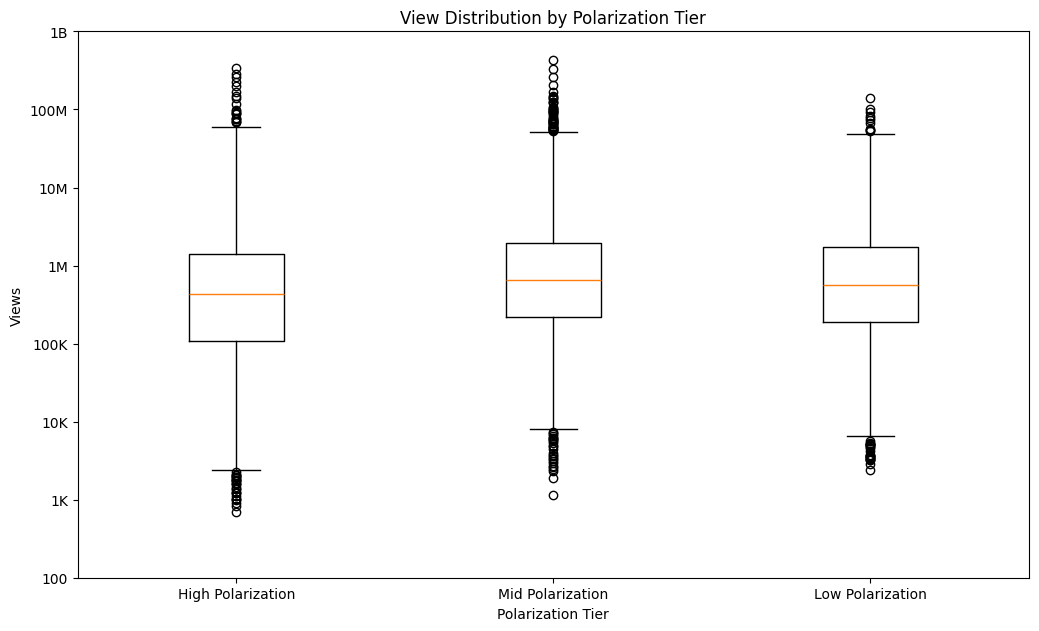

In [48]:
# each tier shares exactly a third of the data
# grouping by tier and median views in log scale
tiers_by_views = all_df_video.groupby('Ratio Tier', observed=True)['views'].apply( # observed True to ignore false values of which are none
    lambda x: np.log10(x)
    .median()
)
print(tiers_by_views)

order = ['High Polarization', 'Mid Polarization', 'Low Polarization']
box_mask = [
    np.log10(all_df_video.loc[all_df_video['Ratio Tier'] == tier, 'views'] + 1)
    for tier in order
    ] # mask for a boxplot of each category in same plot
plt.figure(figsize=(10,6))
plt.boxplot(box_mask, tick_labels=order)
plt.tight_layout()
plt.yticks(
    ticks=[2, 3, 4, 5, 6, 7, 8, 9],
    labels=['100', '1K', '10K', '100K', '1M', '10M', '100M', '1B'] # coverting the yticks back to readable numbers
)
plt.xlabel('Polarization Tier')
plt.ylabel('Views')
plt.title('View Distribution by Polarization Tier')

High Polarization: 10^5.63 ≈ 426k

Mid Polarization: 10^5.81 ≈ 646k

Low Polarization: 10^5.75 ≈ 562k

These are the figures for our 3 quantiles of likes to dislikes ratio. If the client’s hypothesis were correct, the most polarizing tier would exhibit the highest median views. But the highest group is the middle one, Mid Polarization, refuting the client's hypothesis further. Even the boxplots are close to identical.

The analysis shows a strong relationship between views and total engagement metrics including likes, dislikes, and comments, indicating that exposure is more correlative with engagement. However, the like-to-dislike ratio shows only a weak correlation with views (0.10), and highly polarizing videos do not exhibit higher median view counts. Therefore, the data provides little evidence that polarization is a primary driver of engagement. 

One final analysis, I will account for confounding variables like category and likes. Category has not been analyzed yet so next we take a look.

Text(0.5, 1.0, 'Median Likes by Category (log scale)')

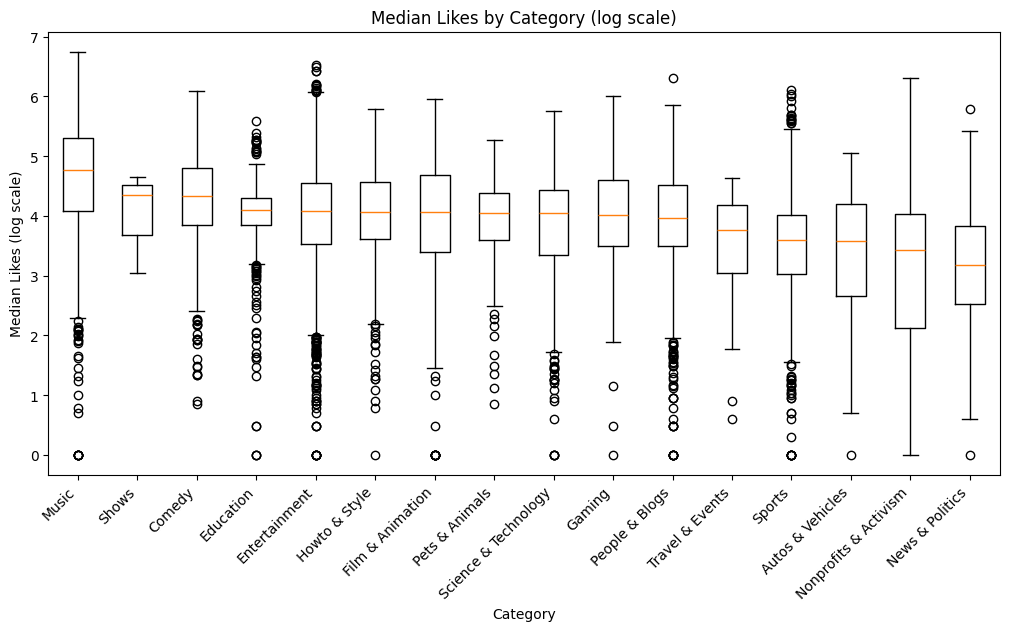

In [52]:
df_copy = all_df_video.copy() # analysis requires log scale, making copy of df to scale
df_copy['log_likes'] = np.log10(df_copy['likes'] + 1)
# creating new df grouped by category and ordered by median likes
order = df_copy.groupby('category_title', observed=False)['log_likes'].median().sort_values(ascending=False).index
box_mask = [df_copy.loc[df_copy['category_title'] == c, 'log_likes'] for c in order] # mask for a boxplot of each category in same plot
plt.figure(figsize=(10,6))
plt.boxplot(box_mask, tick_labels=order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel('Category')
plt.ylabel('Median Likes (log scale)')
plt.title('Median Likes by Category (log scale)')

In [54]:
# Music dominates in median likes while news and politics are the lowest
# Our polarization theory is not being supported still but more calculations to follow
# summary table of median values by categories
summary = (
    all_df_video
    .groupby('category_title', observed=True)
    .agg(
        median_views=('views', 'median'),
        median_likes=('likes', 'median'),
        median_ratio=('likes_to_dislikes', 'median')
    )
    .sort_values('median_views', ascending=False)
)
print(summary)        

                       median_views  median_likes  median_ratio
category_title                                                 
Music                     1636978.0       59067.5     40.031573
Shows                     1351321.0       22587.0     36.667208
Comedy                     786781.0       21279.0     29.579136
Film & Animation           724121.5       11588.5     22.394231
Entertainment              607251.0       11926.0     24.480435
Gaming                     460311.0       10504.0     25.750774
Science & Technology       425445.0       11212.0     27.169420
Pets & Animals             392655.0       11362.0     54.419753
Autos & Vehicles           380530.0        3836.0     18.266479
Sports                     359057.0        4028.0     18.111111
Education                  357602.0       12562.5     32.991785
Travel & Events            356075.0        5901.0     26.549020
Howto & Style              330393.5       11750.5     37.043014
People & Blogs             322896.5     

Music is now more than twice the median views as the next category, Comedy. It also shows a high median ratio meaning much lower "polarization."
Meanwhile, News & Politics is second to last with the lowest median ratio. If we accept our polarization theory, News & Politics should be higher on the list, further disproving our client. This table suggest category type is a strong driver of views and shares.

Next I will model regressions with categories and country as possible confounding variables. To improve the results, I will no longer use the dislike ratio as it is volatile in the highest values. Instead, I will calculate a dislike rate using the total likes and dislikes, binding our value range between 0 and 1.

In [58]:
# log trasnformed views (add 1 to avoid log(0))
df_copy['log_views'] = np.log10(df_copy['views'] + 1)
# log trasnformed likes
df_copy['log_likes'] = np.log10(df_copy['likes'] + 1)
# Create dislike rate (clean polarization metric)
df_copy['dislike_rate'] = df_copy['dislikes'] / (df_copy['likes'] + df_copy['dislikes'] + 1)
model = smf.ols(
    'log_views ~ dislike_rate + C(category_title) + C(country)',
    data=df_copy
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     79.25
Date:                Fri, 01 May 2026   Prob (F-statistic):          2.57e-258
Time:                        18:24:47   Log-Likelihood:                -11421.
No. Observations:                9890   AIC:                         2.288e+04
Df Residuals:                    9872   BIC:                         2.301e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [59]:
# A 1-unit increase in dislike_rate is associated with a 0.38 unit decrease in log_views.
# This suggests negatively received videos are not generating greater reach or views.
# Trying log_likes as a controlled variable
model = smf.ols(
    'log_views ~ dislike_rate + C(category_title) + log_likes',
    data=df_copy
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     2127.
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        18:24:51   Log-Likelihood:                -4440.0
No. Observations:                9890   AIC:                             8916.
Df Residuals:                    9872   BIC:                             9045.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [60]:
# checking engagement rate against dislike rate
df_copy['log_engagement'] = np.log10(df_copy['engagement_rate'] + 1)
model = smf.ols(
    'log_engagement ~ dislike_rate + C(category_title) + C(country)',
    data=df_copy
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_engagement   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     67.58
Date:                Fri, 01 May 2026   Prob (F-statistic):          1.56e-220
Time:                        18:25:01   Log-Likelihood:                 30536.
No. Observations:                9890   AIC:                        -6.104e+04
Df Residuals:                    9872   BIC:                        -6.091e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

When controlling for category and country, dislike rate shows a slight negative association with views. When controlling additionally for total likes, that relationship reversed, and R^2 increases to 0.79, suggesting that among similarly popular videos, disagreement does correspond with a slightly higher reach. However, given the direct causal relationship between views and likes, the results should be interpreted cautiously, and likely is a proxy for "how popular is a video among already-seen videos."

After correcting the engagement rate function, R^2 dropped from 0.16 to 0.11, meaning before the metric was inflated by capturing volume rather than density, which is what the column should measure. However, the findings are similar: higher dislike rates are associated with lower engagement having a coefficient of -0.0146. That means more polarization slightly decreases overall engagement which is a direct refutation of the client's theory. 

In conclusion, this analysis examining a few questions including whether highly polarized YouTube videos received greater engagement and reach. After exploratory analysis, quantile comparisons, and regression modeling, the data does not provide strong evidence that polarization drives views.

Key findings include:
- Views are strongly associated with overall engagement metrics including likes and comments.
- The like-to-dislike ratio shows only a weak relationship with views.
- When controlling for category and country, higher dislikes are associated with slightly lower views.
- Additionally when controlling for likes, the relationship reversed. This effect should be interpreted cautiously due to the direct relationship between views and likes, but the implication is that among similarly viewed videos, disagreement does correspond with higher reach.
- Categories explain the most substantial variation in views rather than polarization.

Overall, the evidence suggests that category and likes are stronger predictors of reach than disagreement. While some data implies polarization can generate some views between similarly levels of shared videos, it does not appear to systematically drive higher view counts in this dataset.

It's important to note we are using views as a measurement of "getting shared the most," which is not the most direct. A direct measurement was not provided and future analysis should incorporate true sharing metrics for better analysis.

Category ID, trending date, tags, and even a breakdown of the description columns could also be investigated further. Categories and tags help tell what content is most popular. We could find key words that help uncover viral terms or phrases that help attract view shares or create a sentiment analysis. And while we used publish date as the default datetime measuremnt, trending times can be analyzed for patterns as well, though it would require more dimensional calculations.